## Perceptron

In [387]:
import numpy as np


In [388]:
# Função Sinal

def sign(z):
    return np.where(z >=0.0, 1.0, 0.0)

In [389]:
# Perceptron

def perceptron(x,w,b):
  z = np.dot(x,w)+b
  return sign(z)

In [390]:
# Treinamento do Perceptron (atualização exemplo por exemplo)

def treinar_perceptron(X, d, eta=0.01, epocas=1000):
    n_amostras, n_atributos = X.shape
    w = np.zeros(n_atributos)
    b =0.0

    for epoca in range(epocas):
        erros_na_epoca = 0
        for i in range(n_amostras):
            x_i = X[i]
            y_esperado = d[i]

            y_pred = perceptron(x_i, w, b)

            erro = y_esperado - y_pred
            if erro != 0:
                w += eta * erro * x_i
                b += eta * erro
                erros_na_epoca += 1

        # Se não houve nenhum erro nesta época, o perceptron convergiu!
        if erros_na_epoca == 0:
            print(f"Convergiu na época {epoca + 1}!")
            break

    return w, b

In [391]:
from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

In [392]:
dados=load_iris()

print(dados.feature_names)
print(dados.target)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [393]:
setosa_versicolor = (dados.target == 0) | (dados.target == 1)
X = dados.data[setosa_versicolor,2:]
y = dados.target[setosa_versicolor]

In [394]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42,stratify=y)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [395]:
np.random.seed(42)
w, b = treinar_perceptron(x_train, y_train)

# Testando no conjunto de teste

y_pred = perceptron(x_test, w,b)

print(f"Acurácia no conjunto de teste: {np.mean(y_pred == y_test)}")

Convergiu na época 2!
Acurácia no conjunto de teste: 1.0


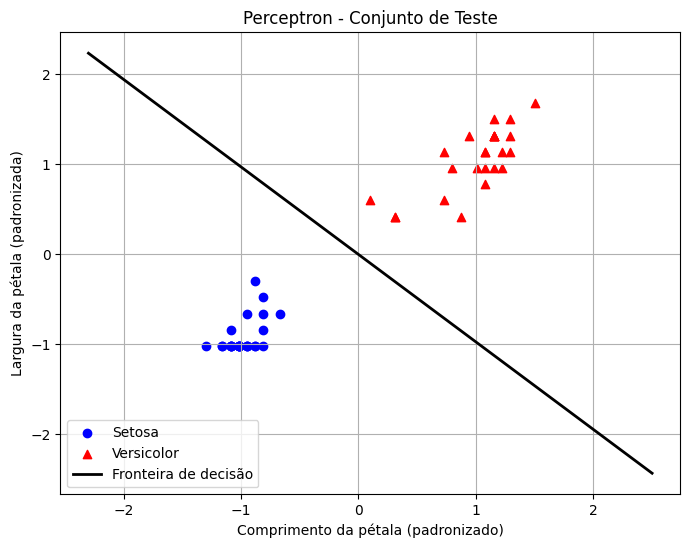

In [396]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================
# Dados de teste
# ==========================
plt.figure(figsize=(8,6))

# Classe 0
plt.scatter(
    x_test[y_test == 0, 0],
    x_test[y_test == 0, 1],
    color='blue',
    marker='o',
    label='Setosa'
)

# Classe 1
plt.scatter(
    x_test[y_test == 1, 0],
    x_test[y_test == 1, 1],
    color='red',
    marker='^',
    label='Versicolor'
)

# ==========================
# Fronteira de decisão
# ==========================
x1 = np.linspace(x_test[:,0].min()-1,
                 x_test[:,0].max()+1, 100)

# w0*x1 + w1*x2 + b = 0
x2 = -(w[0]*x1 + b)/w[1]

plt.plot(x1, x2, 'k-', linewidth=2, label='Fronteira de decisão')

plt.xlabel('Comprimento da pétala (padronizado)')
plt.ylabel('Largura da pétala (padronizada)')
plt.title('Perceptron - Conjunto de Teste')
plt.legend()
plt.grid(True)

plt.show()